In [103]:
import pandas as pd 
import numpy as np 
import sklearn
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

DATA INSPECTION

In [104]:
data = pd.read_csv(r"C:\Users\krish\Downloads\retail_data.csv")

In [105]:
df = data.copy()
df.head(5)

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788.0,37249.0,Michelle Harrington,Ebony39@gmail.com,1.414787e+09,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,...,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773.0,69749.0,Kelsey Hill,Mark36@gmail.com,6.852900e+09,82072 Dawn Centers,Nottingham,England,99071.0,UK,...,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610.0,30192.0,Scott Jensen,Shane85@gmail.com,8.362160e+09,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,...,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460.0,62101.0,Joseph Miller,Mary34@gmail.com,2.776752e+09,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,...,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775.0,27901.0,Debra Coleman,Charles30@gmail.com,9.098268e+09,5813 Lori Ports Suite 269,Bristol,England,48704.0,UK,...,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies


In [106]:
# size of dataset
df.shape

(302010, 30)

In [107]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Name', 'Email', 'Phone', 'Address',
       'City', 'State', 'Zipcode', 'Country', 'Age', 'Gender', 'Income',
       'Customer_Segment', 'Date', 'Year', 'Month', 'Time', 'Total_Purchases',
       'Amount', 'Total_Amount', 'Product_Category', 'Product_Brand',
       'Product_Type', 'Feedback', 'Shipping_Method', 'Payment_Method',
       'Order_Status', 'Ratings', 'products'],
      dtype='object')

In [108]:
df.dtypes

Transaction_ID      float64
Customer_ID         float64
Name                 object
Email                object
Phone               float64
Address              object
City                 object
State                object
Zipcode             float64
Country              object
Age                 float64
Gender               object
Income               object
Customer_Segment     object
Date                 object
Year                float64
Month                object
Time                 object
Total_Purchases     float64
Amount              float64
Total_Amount        float64
Product_Category     object
Product_Brand        object
Product_Type         object
Feedback             object
Shipping_Method      object
Payment_Method       object
Order_Status         object
Ratings             float64
products             object
dtype: object

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302010 entries, 0 to 302009
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction_ID    301677 non-null  float64
 1   Customer_ID       301702 non-null  float64
 2   Name              301628 non-null  object 
 3   Email             301663 non-null  object 
 4   Phone             301648 non-null  float64
 5   Address           301695 non-null  object 
 6   City              301762 non-null  object 
 7   State             301729 non-null  object 
 8   Zipcode           301670 non-null  float64
 9   Country           301739 non-null  object 
 10  Age               301837 non-null  float64
 11  Gender            301693 non-null  object 
 12  Income            301720 non-null  object 
 13  Customer_Segment  301795 non-null  object 
 14  Date              301651 non-null  object 
 15  Year              301660 non-null  float64
 16  Month             30

In [110]:
df.describe()

,Transaction_ID,Customer_ID,Phone,Zipcode,Age,Year,Total_Purchases,Amount,Total_Amount,Ratings
count,3.016770e+05,301702.000000,3.016480e+05,301670.000000,301837.000000,301660.000000,301649.000000,301653.000000,301660.000000,301826.000000
mean,5.495823e+06,55006.553934,5.501464e+09,50298.951019,35.481326,2023.165113,5.359729,255.163659,1367.651156,3.162670
std,2.595565e+06,26005.675200,2.596017e+09,28972.807134,15.021933,0.371283,2.868575,141.389640,1128.998515,1.320827
min,1.000007e+06,10000.000000,1.000049e+09,501.000000,18.000000,2023.000000,1.000000,10.000219,10.003750,1.000000
25%,3.247930e+06,32469.250000,3.255061e+09,25425.000000,22.000000,2023.000000,3.000000,132.890764,438.724278,2.000000
50%,5.499657e+06,55012.000000,5.505812e+09,50602.500000,32.000000,2023.000000,5.000000,255.470969,1041.117547,3.000000
75%,7.739509e+06,77511.000000,7.749860e+09,75252.000000,46.000000,2023.000000,8.000000,377.672606,2029.999853,4.000000
max,9.999995e+06,99999.000000,9.999996e+09,99949.000000,70.000000,2024.000000,10.000000,499.997911,4999.625796,5.000000


In [111]:
df.nunique()

Transaction_ID      294461
Customer_ID          86766
Name                159390
Email                52897
Phone               299295
Address             299329
City                   130
State                   54
Zipcode              93978
Country                  5
Age                     53
Gender                   2
Income                   3
Customer_Segment         3
Date                   366
Year                     2
Month                   12
Time                 83677
Total_Purchases         10
Amount              299297
Total_Amount        299305
Product_Category         5
Product_Brand           18
Product_Type            33
Feedback                 4
Shipping_Method          3
Payment_Method           4
Order_Status             4
Ratings                  5
products               318
dtype: int64

DATA CLEANING

In [112]:
# Finding null vlaues

df.isnull().sum()

Transaction_ID      333
Customer_ID         308
Name                382
Email               347
Phone               362
Address             315
City                248
State               281
Zipcode             340
Country             271
Age                 173
Gender              317
Income              290
Customer_Segment    215
Date                359
Year                350
Month               273
Time                350
Total_Purchases     361
Amount              357
Total_Amount        350
Product_Category    283
Product_Brand       281
Product_Type          0
Feedback            184
Shipping_Method     337
Payment_Method      297
Order_Status        235
Ratings             184
products              0
dtype: int64

C:\Users\krish\AppData\Local\Temp\ipykernel_21496\3755629285.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.index, y=missing_counts.values, palette="viridis")


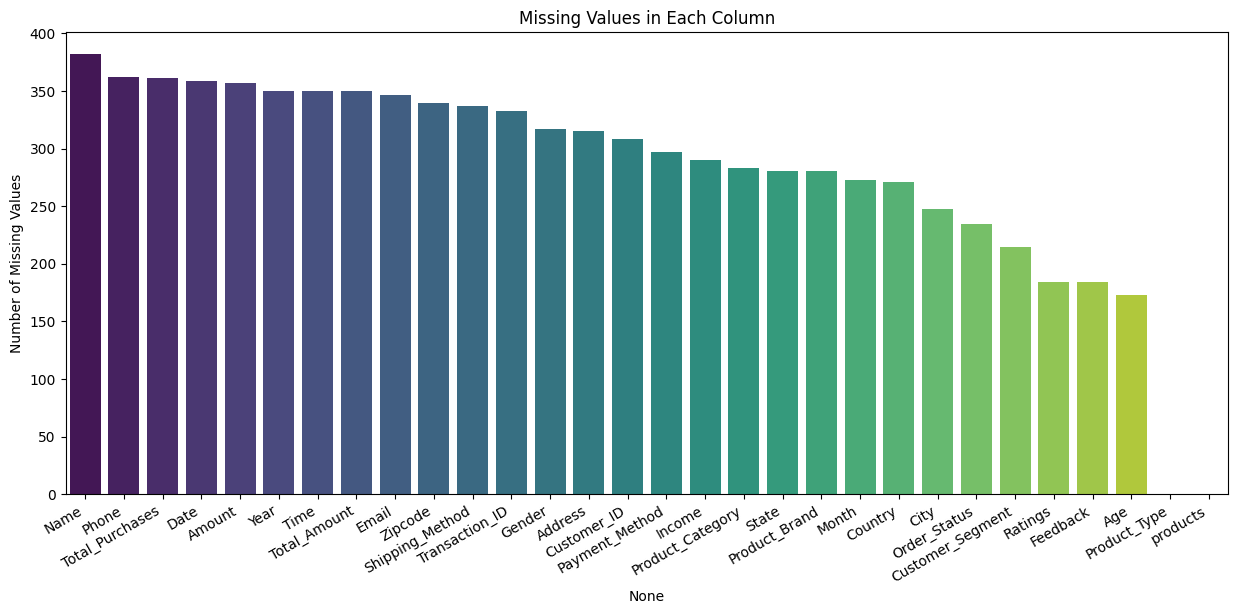

In [113]:
# no.of missing columns in each column
missing_counts = df.isnull().sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(15,6))
sns.barplot(x=missing_counts.index, y=missing_counts.values, palette="viridis")
plt.xticks(rotation=30, ha='right')
plt.ylabel("Number of Missing Values")
plt.title("Missing Values in Each Column")
plt.show()

In [114]:
# Removing null values 

df = df.dropna()
print("After dropping nulls:", df.shape)

After dropping nulls: (293911, 30)


C:\Users\krish\AppData\Local\Temp\ipykernel_21496\2738101167.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.index, y=missing_counts.values, palette="viridis")


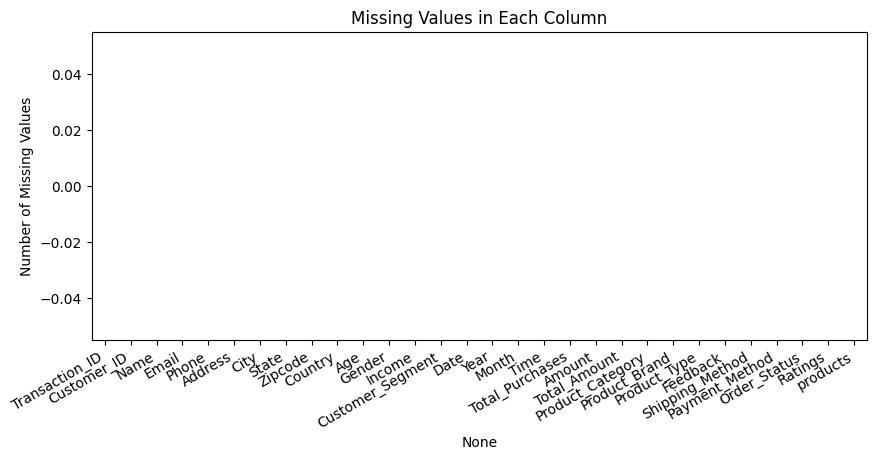

In [115]:
# no.of missing columns after cleaning
missing_counts = df.isnull().sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,4))
sns.barplot(x=missing_counts.index, y=missing_counts.values, palette="viridis")
plt.xticks(rotation=30, ha='right')
plt.ylabel("Number of Missing Values")
plt.title("Missing Values in Each Column")
plt.show()

In [116]:
#Removing duplicate rows 
df.drop_duplicates(inplace = True)
df.shape

(293908, 30)

Correcting Data Types

In [117]:
# Convert all float columns to int
float_cols = df.select_dtypes(include='float').columns

df[float_cols] = df[float_cols].astype('int')

# Check the changes
print(df.dtypes)

Transaction_ID       int64
Customer_ID          int64
Name                object
Email               object
Phone                int64
Address             object
City                object
State               object
Zipcode              int64
Country             object
Age                  int64
Gender              object
Income              object
Customer_Segment    object
Date                object
Year                 int64
Month               object
Time                object
Total_Purchases      int64
Amount               int64
Total_Amount         int64
Product_Category    object
Product_Brand       object
Product_Type        object
Feedback            object
Shipping_Method     object
Payment_Method      object
Order_Status        object
Ratings              int64
products            object
dtype: object


In [ ]:
# import pandas as pd
import numpy as np

# Ensure 'Date' is datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Define min and max dates
min_date = pd.to_datetime('2023-03-13')
max_date = pd.to_datetime('2024-02-29')

# Number of missing dates
n_missing = df['Date'].isnull().sum()

# Generate random dates for missing values
random_dates = pd.to_datetime(np.random.randint(min_date.value//10**9,
                                                max_date.value//10**9,
                                                size=n_missing), unit='s')

# Fill missing dates
df.loc[df['Date'].isnull(), 'Date'] = random_dates

# Remove time part
df['Date'] = df['Date'].dt.date

# Check


print(df['Date'].isnull().sum())  # Should be 0

0


In [123]:
df['Date'] = pd.to_datetime(df['Date']).dt.normalize()

In [127]:
df.head(2)

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788,37249,Michelle Harrington,Ebony39@gmail.com,1414786801,3959 Amanda Burgs,Dortmund,Berlin,77985,Germany,...,324,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5,Cycling shorts
1,2174773,69749,Kelsey Hill,Mark36@gmail.com,6852899987,82072 Dawn Centers,Nottingham,England,99071,UK,...,806,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4,Lenovo Tab


In [128]:
# Save final df as csv 
import os

# Define the folder path and file name
folder_path = "DATA"  # folder already exists
file_name = "Retail Data.csv"
file_path = os.path.join(folder_path, file_name)

# Save the dataframe as CSV
df.to_csv(file_path, index=False)

print(f"File saved successfully at {file_path}")


File saved successfully at DATA\Retail Data.csv
